# Gradient Boosting Regressor — An Illustrated Tour

> Where Random Forest trains trees **in parallel**, Gradient Boosting trains them **sequentially** — each new tree corrects the errors of all previous trees.

---

**What we cover:**
- The core idea: fitting residuals
- Round-by-round growth of the ensemble
- The learning rate — step size control
- Bias-variance tradeoff across boosting rounds
- Early stopping to prevent overfitting
- Feature importance

## The picture — boosting adds tiny learners that fit the residual at each stage

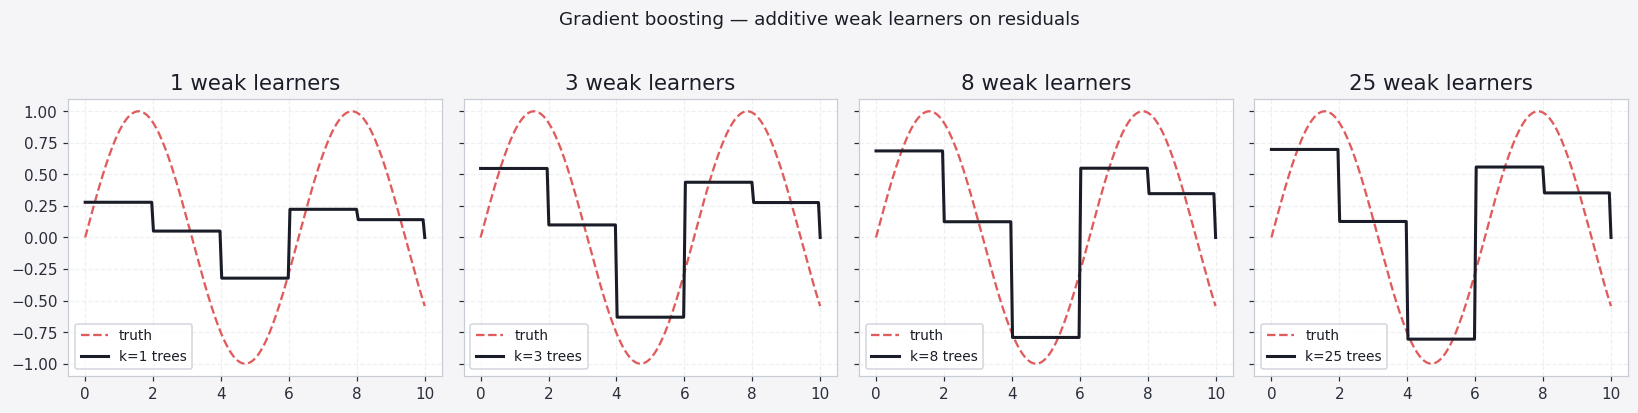

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
x = np.linspace(0, 10, 200); y = np.sin(x)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
preds = np.zeros_like(x)
for ax, k in zip(axes, [1, 3, 8, 25]):
    p = np.zeros_like(x)
    for _ in range(k):
        r = y - p
        cuts = np.linspace(0, 10, 6)
        for i in range(5):
            mask = (x>=cuts[i]) & (x<cuts[i+1])
            p[mask] += 0.4 * r[mask].mean()
    ax.plot(x, y, color=P[1], lw=1.5, ls='--', label='truth')
    ax.plot(x, p, color='#1a1d27', lw=2, label=f'k={k} trees')
    ax.set_title(f'{k} weak learners'); ax.grid(True); ax.legend(fontsize=9)
fig.suptitle('Gradient boosting — additive weak learners on residuals', y=1.03)
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# ── Presentation style ─────────────────────────────────────────────────────
PLT_STYLE = {
    'figure.facecolor':'#f5f5f7', 'axes.facecolor':'#ffffff',
    'axes.edgecolor':'#c8ccd4',   'axes.labelcolor':'#1a1d27',
    'axes.titlecolor':'#1a1d27',  'xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a',      'grid.color':'#e0e3ea',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'text.color':'#1a1d27',       'font.family': 'DejaVu Sans',
    'axes.titlesize': 17,          'axes.labelsize': 13,
    'xtick.labelsize': 11,         'ytick.labelsize': 11,
    'legend.fontsize': 11,         'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4', 'figure.dpi': 120,
}
plt.rcParams.update(PLT_STYLE)

C_DATA  = '#5b9bd5'   # data
C_TREE  = '#e05c5c'   # weak learner / residuals
C_GB    = '#f4b942'   # gradient boosting ensemble
C_TRUE  = '#7ecba1'   # true function
C_HL    = '#56b6c2'   # highlight
C_GRAD  = '#c678dd'   # sequential steps

# ── Dataset ─────────────────────────────────────────────────────────────────
np.random.seed(0)
m      = 80
x_raw  = np.sort(np.random.uniform(0, 6, m))
y_raw  = np.sin(x_raw) + 0.5*np.cos(2*x_raw) + np.random.randn(m) * 0.35

x_pl   = np.linspace(0, 6, 400)
y_true = np.sin(x_pl) + 0.5*np.cos(2*x_pl)

print('Dataset: 80 points  |  non-linear signal + noise')
print('True function: sin(x) + 0.5·cos(2x)')

Dataset: 80 points  |  non-linear signal + noise
True function: sin(x) + 0.5·cos(2x)


---
## The Idea — Learning from Mistakes

Gradient Boosting builds an ensemble **one tree at a time**:

1. Fit a shallow tree to the data
2. Compute the **residuals** — what the current ensemble got wrong
3. Fit the next tree to those residuals
4. Add it to the ensemble (scaled by the learning rate)
5. Repeat

Each tree corrects the errors of all previous trees.

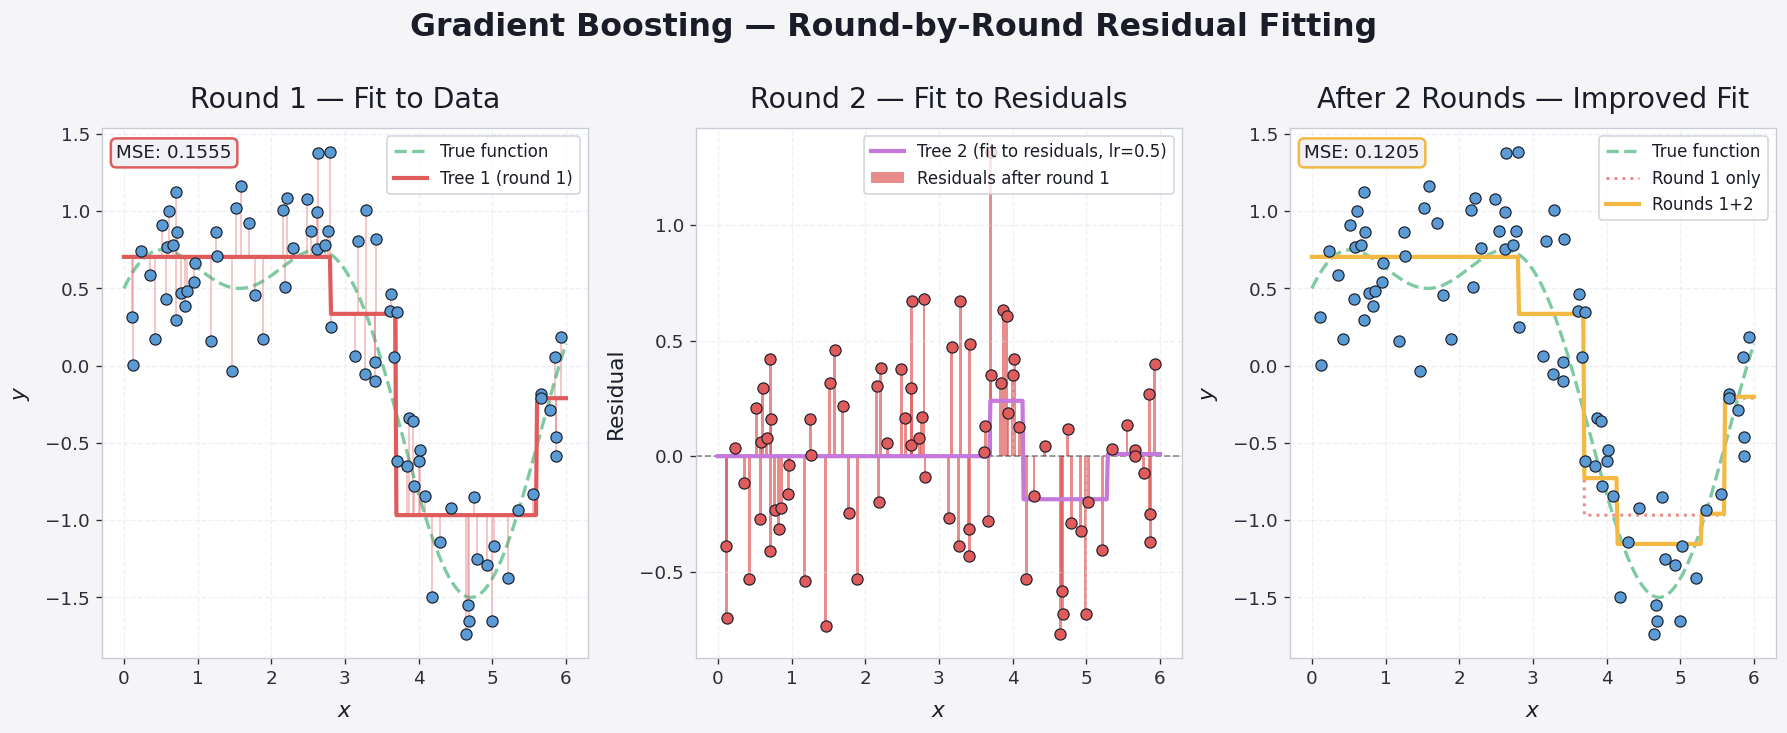

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Manual 2-round boosting illustration
learning_rate = 0.5

# Round 1
tree1 = DecisionTreeRegressor(max_depth=2, random_state=0)
tree1.fit(x_raw.reshape(-1,1), y_raw)
pred1  = tree1.predict(x_raw.reshape(-1,1))
resid1 = y_raw - pred1

# Round 2
tree2 = DecisionTreeRegressor(max_depth=2, random_state=1)
tree2.fit(x_raw.reshape(-1,1), resid1)
pred2_corr = tree2.predict(x_raw.reshape(-1,1))
ensemble2  = pred1 + learning_rate * pred2_corr
resid2     = y_raw - ensemble2

# Plot 1: first tree fit
ax = axes[0]
ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--', label='True function', zorder=2)
ax.plot(x_pl, tree1.predict(x_pl.reshape(-1,1)), color=C_TREE, lw=2.5,
        label='Tree 1 (round 1)', zorder=3)
ax.scatter(x_raw, y_raw, s=45, c=C_DATA, edgecolors='#1a1d27', lw=0.7, zorder=4)
for xi, yi, pi in zip(x_raw, y_raw, pred1):
    ax.plot([xi,xi],[yi,pi], color=C_TREE, lw=1, alpha=0.4)
ax.set_xlabel('$x$', labelpad=8); ax.set_ylabel('$y$', labelpad=8)
ax.set_title('Round 1 — Fit to Data', pad=12)
ax.grid(True); ax.legend(loc='upper right', fontsize=10)
mse1 = mean_squared_error(y_raw, pred1)
ax.text(0.03, 0.97, f'MSE: {mse1:.4f}', transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec=C_TREE, lw=1.5))

# Plot 2: residuals + round 2
ax = axes[1]
ax.axhline(0, color='#1a1d27', lw=1, ls='--', alpha=0.5)
ax.bar(x_raw, resid1, width=0.04, color=C_TREE, alpha=0.7, label='Residuals after round 1')
ax.plot(x_pl, tree2.predict(x_pl.reshape(-1,1)) * learning_rate,
        color=C_GRAD, lw=2.5, label=f'Tree 2 (fit to residuals, lr={learning_rate})')
ax.scatter(x_raw, resid1, s=45, c=C_TREE, edgecolors='#1a1d27', lw=0.7, zorder=4)
ax.set_xlabel('$x$', labelpad=8); ax.set_ylabel('Residual', labelpad=8)
ax.set_title('Round 2 — Fit to Residuals', pad=12)
ax.grid(True); ax.legend(loc='upper right', fontsize=10)

# Plot 3: ensemble after 2 rounds
ax = axes[2]
ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--', label='True function', zorder=2)
ax.plot(x_pl, tree1.predict(x_pl.reshape(-1,1)),
        color=C_TREE, lw=1.8, ls=':', label='Round 1 only', alpha=0.7, zorder=3)
ax.plot(x_pl, (tree1.predict(x_pl.reshape(-1,1))
             + learning_rate * tree2.predict(x_pl.reshape(-1,1))),
        color=C_GB, lw=2.5, label='Rounds 1+2', zorder=4)
ax.scatter(x_raw, y_raw, s=45, c=C_DATA, edgecolors='#1a1d27', lw=0.7, zorder=5)
ax.set_xlabel('$x$', labelpad=8); ax.set_ylabel('$y$', labelpad=8)
ax.set_title('After 2 Rounds — Improved Fit', pad=12)
ax.grid(True); ax.legend(loc='upper right', fontsize=10)
mse2 = mean_squared_error(y_raw, ensemble2)
ax.text(0.03, 0.97, f'MSE: {mse2:.4f}', transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec=C_GB, lw=1.5))

fig.suptitle('Gradient Boosting — Round-by-Round Residual Fitting',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Sequential Growth — The Ensemble Evolves

Watch how the ensemble prediction improves as more rounds are added.
Early rounds make big corrections; later rounds make fine adjustments.

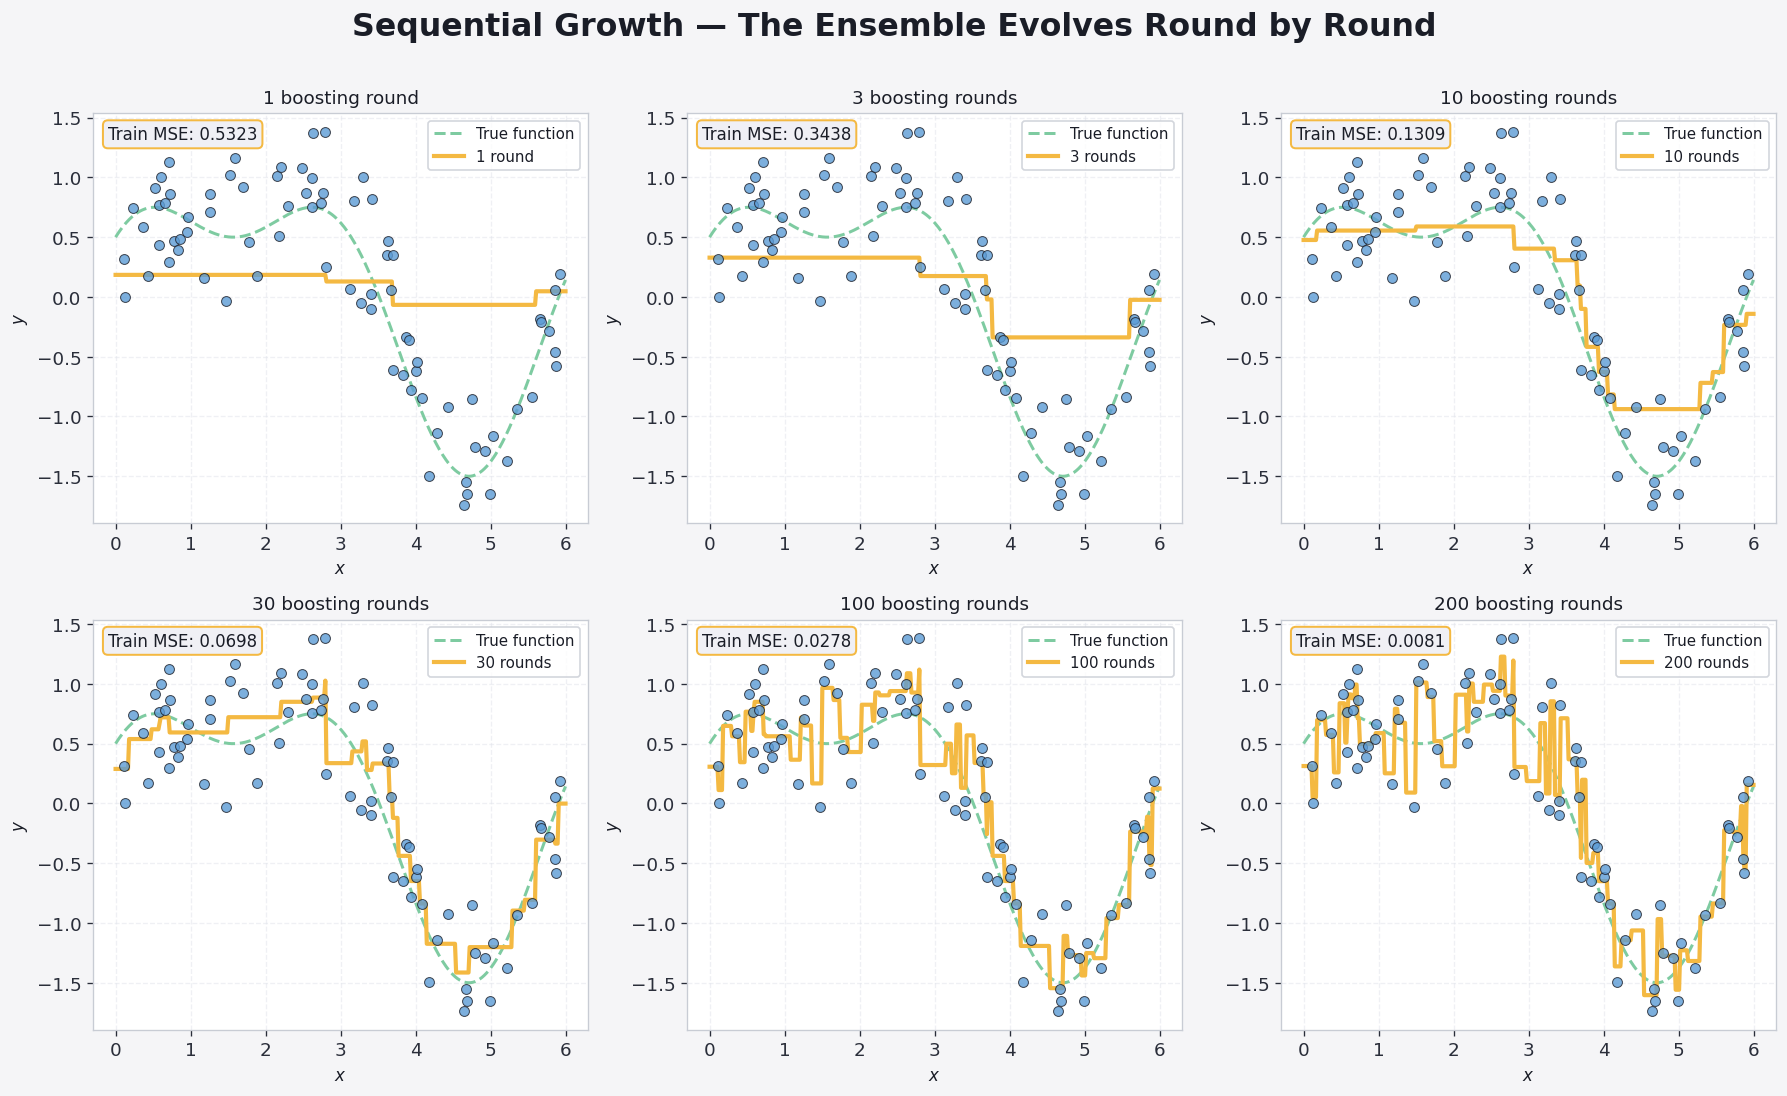

In [4]:
gb_full = GradientBoostingRegressor(n_estimators=200, max_depth=2,
                                     learning_rate=0.15, random_state=0)
gb_full.fit(x_raw.reshape(-1,1), y_raw)

snap_rounds = [1, 3, 10, 30, 100, 200]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, n_rounds in zip(axes, snap_rounds):
    # staged_predict gives predictions after each stage
    pred_n = next(
        p for i, p in enumerate(gb_full.staged_predict(x_pl.reshape(-1,1)),1)
        if i == n_rounds
    )
    pred_train = next(
        p for i, p in enumerate(gb_full.staged_predict(x_raw.reshape(-1,1)),1)
        if i == n_rounds
    )
    mse_n = mean_squared_error(y_raw, pred_train)

    ax.plot(x_pl, y_true, color=C_TRUE, lw=1.8, ls='--', label='True function', zorder=2)
    ax.plot(x_pl, pred_n, color=C_GB, lw=2.5, zorder=3,
            label=f'{n_rounds} round{"s" if n_rounds>1 else ""}')
    ax.scatter(x_raw, y_raw, s=35, c=C_DATA, edgecolors='#1a1d27', lw=0.6,
               alpha=0.8, zorder=4)
    ax.set_xlabel('$x$', fontsize=10); ax.set_ylabel('$y$', fontsize=10)
    ax.set_title(f'{n_rounds} boosting round{"s" if n_rounds>1 else ""}', fontsize=11)
    ax.grid(True); ax.legend(loc='upper right', fontsize=9)
    ax.text(0.03, 0.97, f'Train MSE: {mse_n:.4f}',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', fc='#f0f0f5', ec=C_GB, lw=1.2))

fig.suptitle('Sequential Growth — The Ensemble Evolves Round by Round',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## The Learning Rate

The **learning rate** $\eta$ scales each tree's contribution:
$$F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$$

- Large $\eta$ → fast learning, but risks overshooting → **overfit**
- Small $\eta$ → slow but more regularised → usually **better generalisation** (but needs more trees)

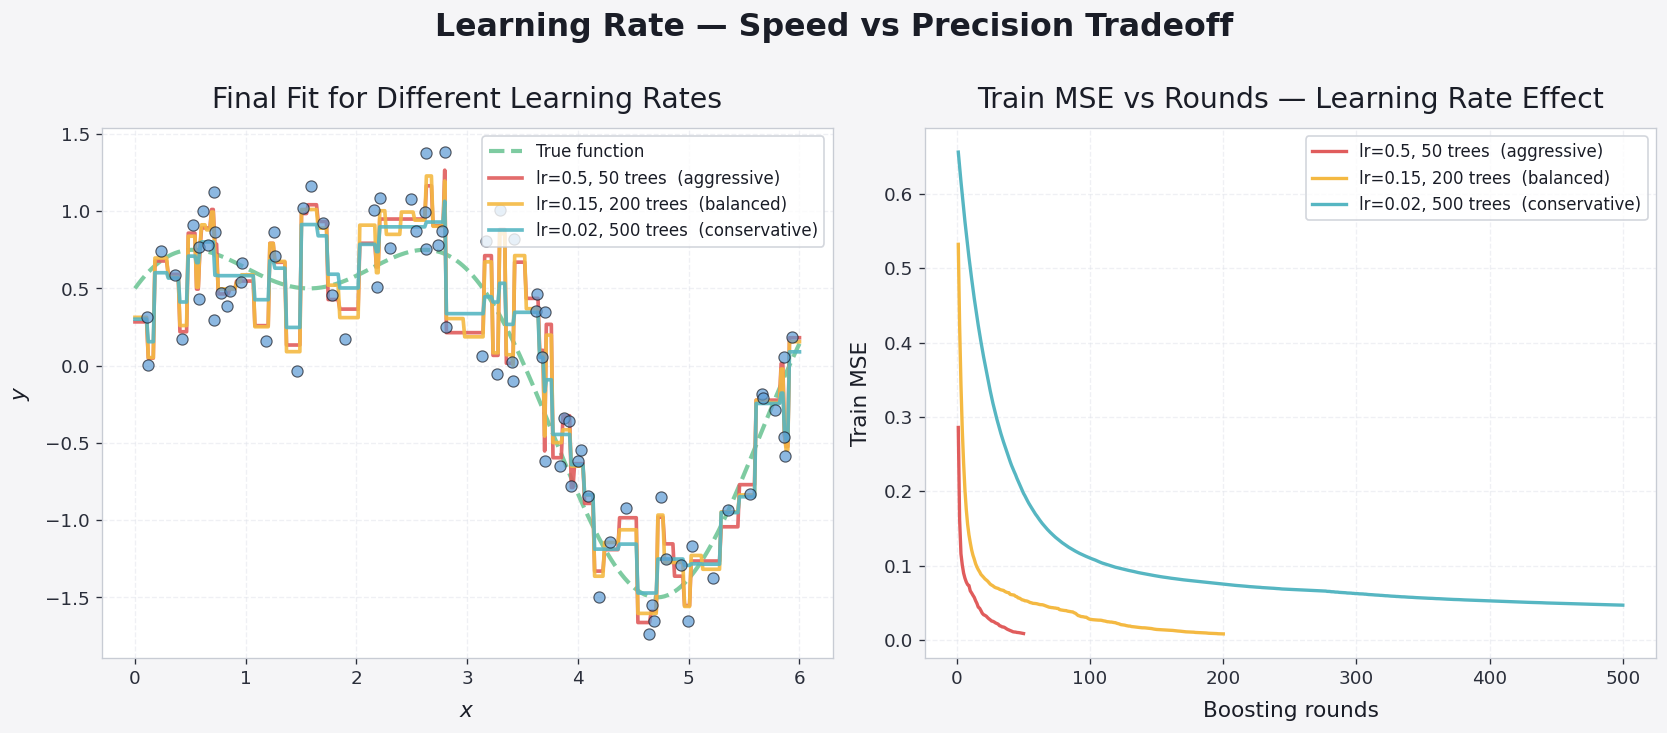

In [5]:
configs = [
    (0.5,  50,  C_TREE, 'lr=0.5, 50 trees  (aggressive)'),
    (0.15, 200, C_GB,   'lr=0.15, 200 trees  (balanced)'),
    (0.02, 500, C_HL,   'lr=0.02, 500 trees  (conservative)'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: final fits
ax = axes[0]
ax.plot(x_pl, y_true, color=C_TRUE, lw=2.5, ls='--', label='True function', zorder=2)
ax.scatter(x_raw, y_raw, s=45, c=C_DATA, edgecolors='#1a1d27', lw=0.7, alpha=0.7, zorder=3)

for lr, n_est, col, lbl in configs:
    gb = GradientBoostingRegressor(n_estimators=n_est, max_depth=2,
                                    learning_rate=lr, random_state=0)
    gb.fit(x_raw.reshape(-1,1), y_raw)
    ax.plot(x_pl, gb.predict(x_pl.reshape(-1,1)), color=col, lw=2.2, label=lbl, alpha=0.9)

ax.set_xlabel('$x$', labelpad=8); ax.set_ylabel('$y$', labelpad=8)
ax.set_title('Final Fit for Different Learning Rates', pad=12)
ax.grid(True); ax.legend(loc='upper right', fontsize=10)

# Right: train MSE as rounds accumulate for each config
ax = axes[1]
for lr, n_est, col, lbl in configs:
    gb = GradientBoostingRegressor(n_estimators=n_est, max_depth=2,
                                    learning_rate=lr, random_state=0)
    gb.fit(x_raw.reshape(-1,1), y_raw)
    stage_mse = [mean_squared_error(y_raw, p)
                 for p in gb.staged_predict(x_raw.reshape(-1,1))]
    ax.plot(range(1, len(stage_mse)+1), stage_mse, color=col, lw=2, label=lbl)

ax.set_xlabel('Boosting rounds', labelpad=8)
ax.set_ylabel('Train MSE', labelpad=8)
ax.set_title('Train MSE vs Rounds — Learning Rate Effect', pad=12)
ax.grid(True); ax.legend(loc='upper right', fontsize=10)

fig.suptitle('Learning Rate — Speed vs Precision Tradeoff',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Overfitting and Early Stopping

With too many rounds, Gradient Boosting **overfits** — train error keeps dropping but test error starts rising.
Monitor test error and stop when it starts to increase.

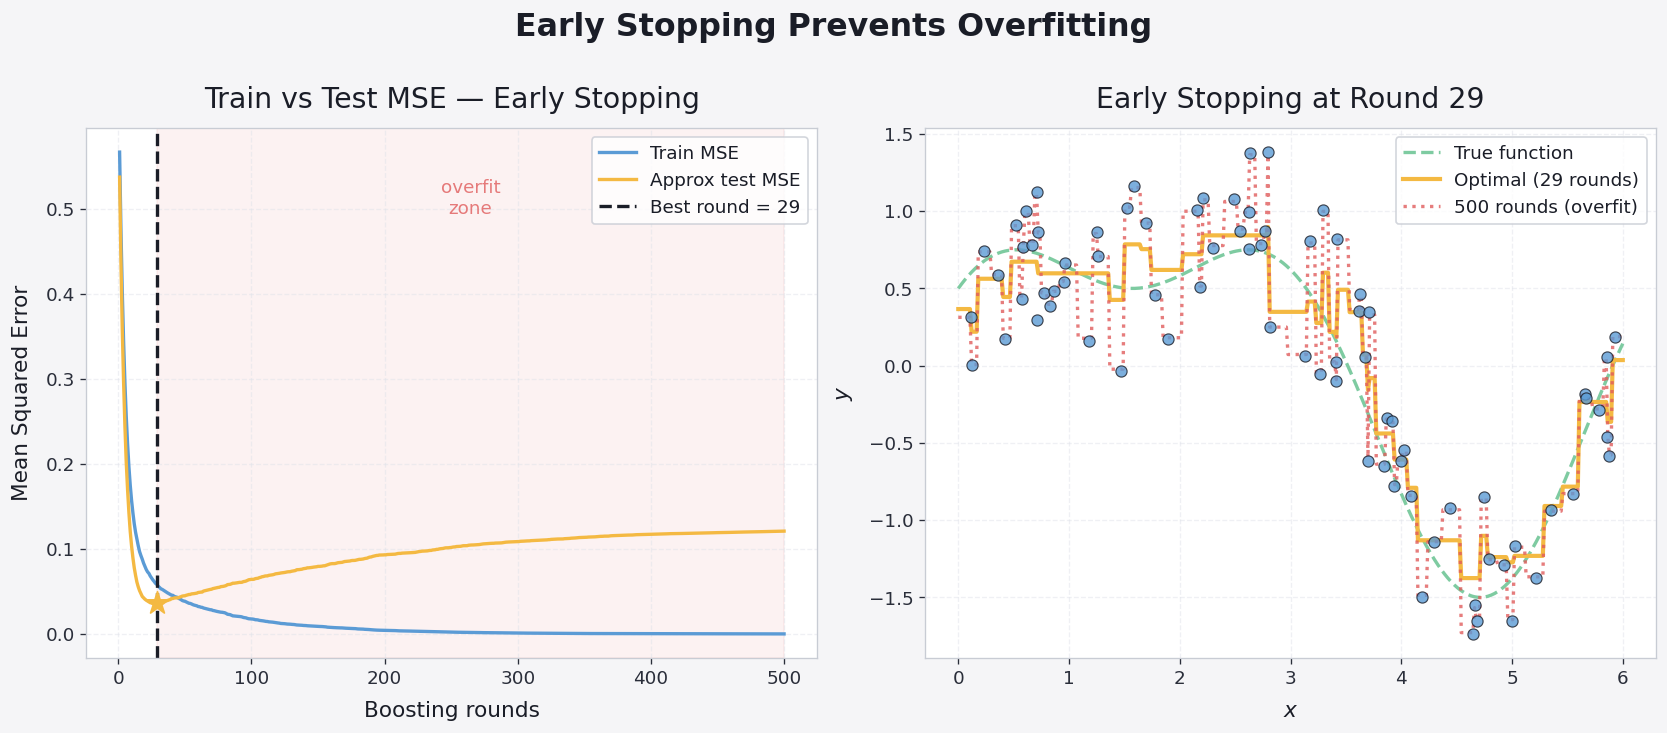

In [6]:
# Use staged_predict to track both train and test MSE per round
gb_stages = GradientBoostingRegressor(n_estimators=500, max_depth=3,
                                        learning_rate=0.1, random_state=0)
gb_stages.fit(x_raw.reshape(-1,1), y_raw)

train_mse_stages = [mean_squared_error(y_raw, p)
                    for p in gb_stages.staged_predict(x_raw.reshape(-1,1))]
test_mse_stages  = [mean_squared_error(y_true, p)
                    for p in gb_stages.staged_predict(x_pl.reshape(-1,1))]

best_round = int(np.argmin(test_mse_stages)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: train & test MSE per round
ax = axes[0]
rounds = np.arange(1, 501)
ax.plot(rounds, train_mse_stages, color=C_DATA, lw=2, label='Train MSE')
ax.plot(rounds, test_mse_stages,  color=C_GB,   lw=2, label='Approx test MSE')
ax.axvline(best_round, color='#1a1d27', ls='--', lw=2,
           label=f'Best round = {best_round}')
ax.scatter([best_round], [test_mse_stages[best_round-1]],
           s=200, c=C_GB, marker='*', zorder=7)
ax.set_xlabel('Boosting rounds', labelpad=8)
ax.set_ylabel('Mean Squared Error', labelpad=8)
ax.set_title('Train vs Test MSE — Early Stopping', pad=12)
ax.grid(True); ax.legend(loc='upper right')

# Annotate overfit zone
ax.axvspan(best_round, 500, color=C_TREE, alpha=0.08)
ax.text((best_round+500)/2, max(test_mse_stages)*0.92, 'overfit\nzone',
        ha='center', fontsize=11, color=C_TREE, alpha=0.8)

# Right: prediction at optimal round vs over-boosted
gb_best = GradientBoostingRegressor(n_estimators=best_round, max_depth=3,
                                     learning_rate=0.1, random_state=0)
gb_best.fit(x_raw.reshape(-1,1), y_raw)

ax = axes[1]
ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--', label='True function', zorder=2)
ax.plot(x_pl, gb_best.predict(x_pl.reshape(-1,1)),
        color=C_GB, lw=2.5, label=f'Optimal ({best_round} rounds)', zorder=3)
ax.plot(x_pl, gb_stages.predict(x_pl.reshape(-1,1)),
        color=C_TREE, lw=2, ls=':', label='500 rounds (overfit)', alpha=0.8, zorder=3)
ax.scatter(x_raw, y_raw, s=45, c=C_DATA, edgecolors='#1a1d27', lw=0.7, alpha=0.8, zorder=4)
ax.set_xlabel('$x$', labelpad=8); ax.set_ylabel('$y$', labelpad=8)
ax.set_title(f'Early Stopping at Round {best_round}', pad=12)
ax.grid(True); ax.legend(loc='upper right')

fig.suptitle('Early Stopping Prevents Overfitting',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## 🎛️ Try It Yourself — Dial η and n_estimators

Two knobs control the boosting tradeoff: the **learning rate η** (how big each
correction is) and the **number of rounds**. They interact: small η needs
many rounds; large η + many rounds is the fast road to overfitting.

Watch the live fit on the left and the train/test trajectory on the right —
the white vertical line marks your current round, and the green star marks
the best test round so far.


---
## Feature Importance

Like Random Forest, Gradient Boosting scores each feature by its total impurity reduction across all splits in all trees.

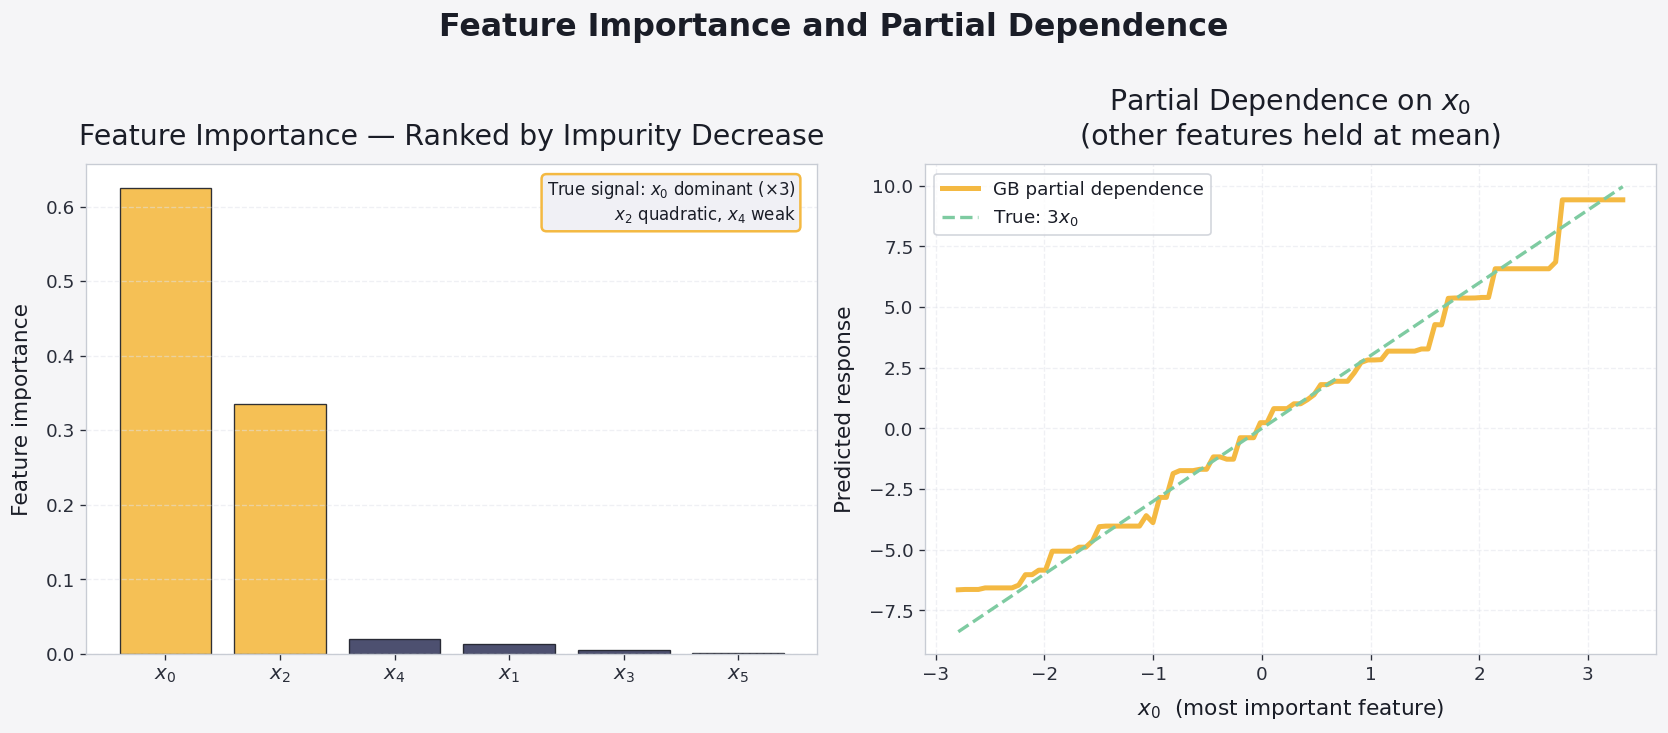

In [7]:
# Multi-feature dataset (same as RF notebook for comparability)
np.random.seed(1)
m2   = 200
x_mf = np.random.randn(m2, 6)
y_mf = 3*x_mf[:,0] - 2*x_mf[:,2]**2 + 0.5*x_mf[:,4] + 0.3*np.random.randn(m2)

gb_imp = GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                    learning_rate=0.1, random_state=42)
gb_imp.fit(x_mf, y_mf)
importances = gb_imp.feature_importances_
feature_names = [f'$x_{j}$' for j in range(6)]
sort_idx = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: importance bar
ax = axes[0]
cols = [C_GB if importances[i] > 0.15 else C_HL if importances[i] > 0.03 else '#3a3d60'
        for i in sort_idx]
ax.bar(range(6), importances[sort_idx], color=cols, edgecolor='#1a1d27', lw=0.8, alpha=0.9)
ax.set_xticks(range(6))
ax.set_xticklabels([feature_names[i] for i in sort_idx], fontsize=12)
ax.set_ylabel('Feature importance', labelpad=8)
ax.set_title('Feature Importance — Ranked by Impurity Decrease', pad=12)
ax.grid(True, axis='y')
ax.text(0.97, 0.97, 'True signal: $x_0$ dominant ($×3$)\n$x_2$ quadratic, $x_4$ weak',
        transform=ax.transAxes, fontsize=10, va='top', ha='right',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec=C_GB, lw=1.5))

# Right: partial dependence style — prediction vs x0 (most important)
ax = axes[1]
x_pd = np.zeros((100, 6))
x_pd[:, 0] = np.linspace(x_mf[:,0].min(), x_mf[:,0].max(), 100)
for j in range(1, 6):
    x_pd[:, j] = x_mf[:, j].mean()
pd_pred = gb_imp.predict(x_pd)

ax.plot(x_pd[:, 0], pd_pred, color=C_GB, lw=3, label='GB partial dependence')
ax.plot(x_pd[:, 0], 3 * x_pd[:, 0], color=C_TRUE, lw=2, ls='--',
        label='True: $3x_0$')
ax.set_xlabel('$x_0$  (most important feature)', labelpad=8)
ax.set_ylabel('Predicted response', labelpad=8)
ax.set_title('Partial Dependence on $x_0$\n(other features held at mean)', pad=12)
ax.grid(True); ax.legend(loc='upper left')

fig.suptitle('Feature Importance and Partial Dependence',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Everything on One Canvas

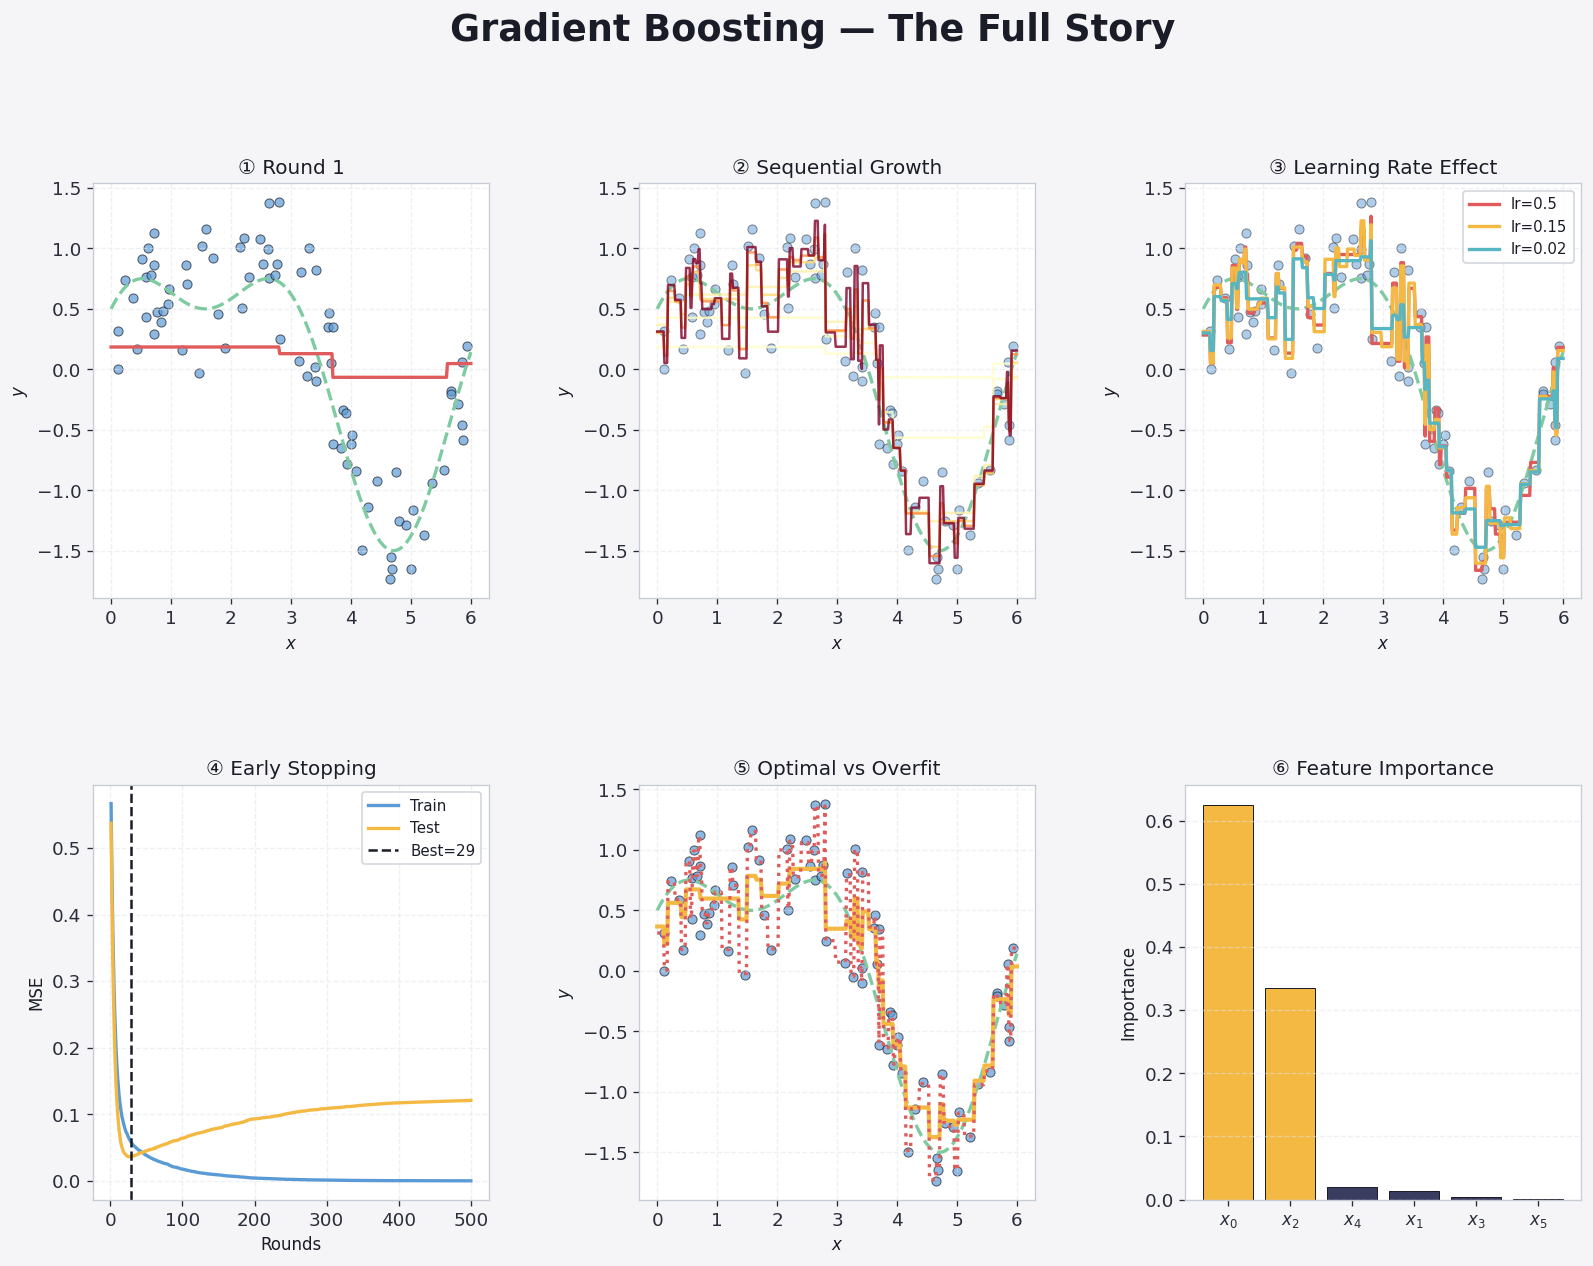

In [8]:
fig = plt.figure(figsize=(16, 11), facecolor='#f5f5f7')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── (0,0) Round 1 ────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
pred_r1 = next(gb_full.staged_predict(x_pl.reshape(-1,1)))
ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--')
ax.plot(x_pl, pred_r1, color=C_TREE, lw=2)
ax.scatter(x_raw, y_raw, s=30, c=C_DATA, edgecolors='#1a1d27', lw=0.6, alpha=0.7)
ax.grid(True)
ax.set_title('① Round 1', fontsize=12)
ax.set_xlabel('$x$', fontsize=10); ax.set_ylabel('$y$', fontsize=10)

# ── (0,1) Sequential snapshots ───────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--')
cmap_seq = plt.cm.YlOrRd
for n_r in [1, 5, 20, 50, 100, 200]:
    pred_nr = next(
        p for i, p in enumerate(gb_full.staged_predict(x_pl.reshape(-1,1)),1)
        if i == n_r
    )
    ax.plot(x_pl, pred_nr, color=cmap_seq(n_r/200), lw=1.5, alpha=0.8)
ax.scatter(x_raw, y_raw, s=30, c=C_DATA, edgecolors='#1a1d27', lw=0.6, alpha=0.5)
ax.grid(True)
ax.set_title('② Sequential Growth', fontsize=12)
ax.set_xlabel('$x$', fontsize=10); ax.set_ylabel('$y$', fontsize=10)

# ── (0,2) Learning rate effect ───────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--')
for lr, n_est, col, lbl in configs:
    gb_lr = GradientBoostingRegressor(n_estimators=n_est, max_depth=2,
                                       learning_rate=lr, random_state=0)
    gb_lr.fit(x_raw.reshape(-1,1), y_raw)
    ax.plot(x_pl, gb_lr.predict(x_pl.reshape(-1,1)), color=col, lw=2, label=f'lr={lr}')
ax.scatter(x_raw, y_raw, s=30, c=C_DATA, edgecolors='#1a1d27', lw=0.6, alpha=0.5)
ax.grid(True); ax.legend(fontsize=9, loc='upper right')
ax.set_title('③ Learning Rate Effect', fontsize=12)
ax.set_xlabel('$x$', fontsize=10); ax.set_ylabel('$y$', fontsize=10)

# ── (1,0) Train vs test MSE ──────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(rounds, train_mse_stages, color=C_DATA, lw=2, label='Train')
ax.plot(rounds, test_mse_stages,  color=C_GB,   lw=2, label='Test')
ax.axvline(best_round, color='#1a1d27', ls='--', lw=1.5, label=f'Best={best_round}')
ax.set_title('④ Early Stopping', fontsize=12)
ax.set_xlabel('Rounds', fontsize=10); ax.set_ylabel('MSE', fontsize=10)
ax.grid(True); ax.legend(fontsize=9)

# ── (1,1) Best vs overfit ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--')
ax.plot(x_pl, gb_best.predict(x_pl.reshape(-1,1)), color=C_GB, lw=2.5)
ax.plot(x_pl, gb_stages.predict(x_pl.reshape(-1,1)), color=C_TREE, lw=2, ls=':')
ax.scatter(x_raw, y_raw, s=30, c=C_DATA, edgecolors='#1a1d27', lw=0.6, alpha=0.7)
ax.grid(True)
ax.set_title('⑤ Optimal vs Overfit', fontsize=12)
ax.set_xlabel('$x$', fontsize=10); ax.set_ylabel('$y$', fontsize=10)

# ── (1,2) Feature importance ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.bar(range(6), importances[sort_idx], color=cols, edgecolor='#1a1d27', lw=0.6)
ax.set_xticks(range(6))
ax.set_xticklabels([feature_names[i] for i in sort_idx], fontsize=10)
ax.set_title('⑥ Feature Importance', fontsize=12)
ax.set_ylabel('Importance', fontsize=10)
ax.grid(True, axis='y')

fig.suptitle('Gradient Boosting — The Full Story',
             fontsize=22, fontweight='bold', color='#1a1d27', y=1.01)
plt.show()

---
## ⚖️ When to use Gradient Boosting — and when not to

| Situation | GB | Random Forest | XGBoost / LightGBM | Linear |
|---|---|---|---|---|
| Top accuracy on tabular | ✅ | usually 2nd | ✅ faster, regularised | ❌ |
| Robust to default hp | ❌ tune learning rate | ✅ | partial | ✅ |
| Big data ($n > 10^6$) | slow | medium | ✅ designed for it | fastest |
| Highly imbalanced classes | partial | partial | ✅ built-in weighting | ❌ |

> Use plain GB for **mid-size tabular** when you have time to tune `learning_rate` × `n_estimators`. Switch to LightGBM/XGBoost for production.


---
## 🎯 Try this

1. **Early stopping.** Add a validation set and stop adding trees once validation loss plateaus. Compare to a model trained for 1000 rounds.
2. **Loss surgery.** Switch from squared loss to Huber and refit on data with outliers. The fit should bend less toward the bad points.
3. **Feature importance vs SHAP.** Plot `feature_importances_` and SHAP values for the same model. They often disagree — explain why for at least one feature.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Weak learner | Shallow decision tree (depth 2–4) | High bias, low variance |
| Residuals | $r_i = y_i - F_{t-1}(x_i)$ — what's left to explain | Next tree fits these, not the original $y$ |
| Ensemble update | $F_t(x) = F_{t-1}(x) + \eta\, h_t(x)$ | Each tree corrects the previous ensemble |
| Learning rate $\eta$ | Scales each tree's contribution | Small $\eta$ → more regularised, needs more trees |
| Boosting rounds | Number of trees added sequentially | More → lower bias; too many → overfit |
| Early stopping | Stop when test error starts rising | Essential for tuning n_estimators |
| Feature importance | Total impurity decrease per feature | Useful for feature selection / interpretation |

| | Random Forest | Gradient Boosting |
|---|---|---|
| Training | Parallel (independent trees) | Sequential (each tree depends on previous) |
| Variance | Reduced by averaging | Reduced by small learning rate |
| Bias | Reduced by deep trees | Reduced by adding more rounds |
| Overfitting risk | Low (averaging) | Higher — needs tuning / early stopping |
| Speed | Faster to train | Slower (sequential) |

**Key insight:** Gradient Boosting fits residuals sequentially — each tree corrects the mistakes of all previous trees. The learning rate controls how aggressively each tree is applied, and early stopping prevents the ensemble from memorising the training data.